---
title: Surface Water Level Monitoring with Sentinel-2
subtitle: Timeseries of water covered area at Santa Giustina lake, Italy
authors:
  - name: Juraj Zvolenský
    orcid: 0009-0000-9185-7955
    github: jzvolensky
    affiliations:
      - id: Eurac Research
        institution: Eurac Research
        ror: 01xt1w755
  - name: Michele Claus
    orcid: 0000-0003-3680-381X
    github: clausmichele
    affiliations:
      - id: Eurac Research
        institution: Eurac Research
        ror: 01xt1w755
date: 2025-10-07
thumbnail: https://raw.githubusercontent.com/EOPF-Sample-Service/eopf-sample-notebooks/refs/heads/main/notebooks/static/ESA_logo_2020_Deep.png
tags: ["sentinel-2", "climate-change", "xarray"]
releaseDate: 2025-10-07
datePublished: 2025-10-07
dateModified: 2025-10-07
github: https://github.com/EOPF-Sample-Service/eopf-sample-notebooks
license: Apache-2.0
---


```{image} ../static/EOPF-on-bright-baseline.png
:alt: ESA EOPF Zarr Logo
:width: 250px
:align: center
```


## Table of contents

- [Introduction](#Introduction_water)
- [Setup](#Setup_water)
- [Access data](#Access_data_water)
- [Visualize datacube sample](#Visualize_datacube_sample_water)
- [Cloud masking](#Cloud_masking_water)
- [NDWI](#NDWI_water)
- [Water detection](#Water_detection_water)
- [Water surface area extraction](#Water_surface_area_extraction_water)


(Introduction_water)=

## Introduction

This notebook demonstrates how to estimate and visualize surface water area measurements at Santa Giustina lake, Italy, using Sentinel-2 data stored in EOPF-Zarr format.

## The lake

Lago di Santa Giustina is an artificial lake located in the Trentino region of northern Italy. It was created in the 1950s by damming the Noce River for hydroelectric power generation. The lake is situated at an elevation of approximately 500 meters above sea level and has a surface area of about 3.5 square kilometers.

![Lago di Santa Giustina](../static/lago-santa-gustina.png)

Image source: By Mosco - Own work, CC BY-SA 3.0, https://commons.wikimedia.org/w/index.php?curid=5144281


:::{hint} Overview

**Questions**

- How can we detect water bodies using Sentinel-2 imagery?
- How can we extract water level measurements from EOPF-Zarr data?
- How can we visualize the water level timeseries?

**Objectives**

- Filter the data so that only almost cloud-free observations are retained
- Detect the water body using NDWI (Normalized Difference Water Index)
- Extract water level measurements using Otsu threshold
- Visualize the water level timeseries

:::


(Setup_water)=

## Setup

Start importing the necessary libraries


In [ ]:
import xarray as xr
import rioxarray
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

import pystac_client

from rasterio.features import geometry_mask

from skimage.filters import threshold_otsu
import pandas as pd
from skimage import measure

from pyproj import Transformer

import dask
from dask_gateway import Gateway

import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [2]:
"""
gate = Gateway("https://dask.user.eopf.eodc.eu",
               proxy_address="tls://dask.user.eopf.eodc.eu:10000",
               auth="jupyterhub")
"""

# Dask Gateway automatically loads the correct configuration.
# So the code below is identical to the comment above
gate = Gateway()
cluster = gate.new_cluster()
cluster.scale(8)

In [3]:
client = cluster.get_client()
client

Connection method: Cluster object,Cluster type: dask_gateway.GatewayCluster
Dashboard: https://dask.user.eopf.eodc.eu/clusters/binderhub.b722f671b4fe49038f9d6ca0a1a35327/status,


(Access_data_water)=

## Access data

Query the EOPF Sentinel-2 STAC Collection for the area and time of interest.

In [7]:
catalog = pystac_client.Client.open("https://stac.core.eopf.eodc.eu")
bbox = [
    11.003288060439315,
    46.34055268553584,
    11.10369555555596,
    46.40183319621778,
]
items = list(
    catalog.search(
        collections=["sentinel-2-l2a"],
        bbox=bbox,
        datetime=["2020-12-31", "2024-01-01"],
    ).items()
)
print(f"items found: {len(items)}")

items found: 434


Combine the products into a single datacube:

In [11]:
%%time


def reproject_bbox(bbox, src_crs="EPSG:4326", dst_crs="EPSG:32632"):
    transformer = Transformer.from_crs(src_crs, dst_crs, always_xy=True)
    xmin, ymin = transformer.transform(bbox[0], bbox[1])
    xmax, ymax = transformer.transform(bbox[2], bbox[3])
    return [xmin, ymin, xmax, ymax]


def load_tile(item, bbox_ll):
    href = item.assets["product"].href
    ds = xr.open_datatree(href, engine="zarr", chunks={}, mask_and_scale=True)

    dst_crs = item.properties.get("proj:code")
    if dst_crs is None:
        raise ValueError(f"No proj:code in item {item.id}")

    utm_bbox = reproject_bbox(bbox_ll, dst_crs=dst_crs)

    ds_ref = (
        ds["measurements"]["reflectance"]["r20m"]
        .to_dataset()[["b02", "b03", "b04", "b8a"]]
        .sel(x=slice(utm_bbox[0], utm_bbox[2]), y=slice(utm_bbox[3], utm_bbox[1]))
        .expand_dims(time=[item.datetime])
    )

    ds_scl = (
        ds["conditions"]["mask"]["l2a_classification"]["r20m"]
        .to_dataset()
        .sel(x=slice(utm_bbox[0], utm_bbox[2]), y=slice(utm_bbox[3], utm_bbox[1]))
        .expand_dims(time=[item.datetime])
    )

    return xr.merge([ds_ref, ds_scl])


delayed_results = [dask.delayed(load_tile)(item, bbox) for item in items]
results = dask.compute(*delayed_results)

# Get CRS from STAC item
crs = items[0].properties.get("proj:code")

datacube = xr.concat(results, dim="time").sortby("time")

datacube = datacube.rio.write_crs(crs, inplace=True)
datacube

CPU times: user 3.12 s, sys: 181 ms, total: 3.3 s
Wall time: 35.2 s


<xarray.Dataset> Size: 2GB
Dimensions:      (time: 434, y: 350, x: 377)
Coordinates:
  * time         (time) object 3kB 1609496609024000000 ... 1703844871024000000
  * x            (x) float32 2kB 6.542e+05 6.542e+05 ... 6.617e+05 6.617e+05
  * y            (y) float32 1kB 5.141e+06 5.141e+06 ... 5.134e+06 5.134e+06
    spatial_ref  int64 8B 0
Data variables:
    b02          (time, y, x) float64 458MB dask.array<chunksize=(1, 350, 37), meta=np.ndarray>
    b03          (time, y, x) float64 458MB dask.array<chunksize=(1, 350, 37), meta=np.ndarray>
    b04          (time, y, x) float64 458MB dask.array<chunksize=(1, 350, 37), meta=np.ndarray>
    b8a          (time, y, x) float64 458MB dask.array<chunksize=(1, 350, 37), meta=np.ndarray>
    scl          (time, y, x) float64 458MB dask.array<chunksize=(1, 350, 37), meta=np.ndarray>

Open the geoJSON file containing the lake boundaries:

In [12]:
lake_gdf = gpd.read_file("./geojson/lago_santa_giustina.geojson")
lake_gdf = lake_gdf.to_crs(crs)

(Visualize_datacube_sample_water)=

## Visualize datacube sample

In this section we visualize an RGB composite for a random date and use the lake polygon as an outline to see if it is aligned correctly.


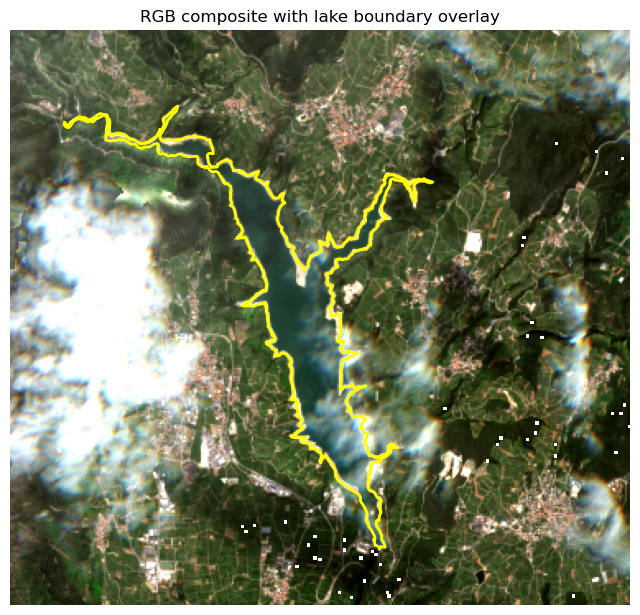

In [13]:
datacube_sample = datacube.isel(time=50)

rgb = datacube_sample[["b04", "b03", "b02"]].to_dataarray(dim="band")

rgb = rgb.assign_coords(band=["red", "green", "blue"])

vmin, vmax = 0, 0.25
rgb_scaled = (rgb - vmin) / (vmax - vmin)
rgb_scaled = rgb_scaled.clip(0, 1)

rgb_img = rgb_scaled.transpose("y", "x", "band").values

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(
    rgb_img,
    extent=[
        float(rgb.x.min()),
        float(rgb.x.max()),
        float(rgb.y.min()),
        float(rgb.y.max()),
    ],
)

lake_gdf.boundary.plot(ax=ax, edgecolor="yellow", linewidth=2)
ax.set_title("RGB composite with lake boundary overlay")
ax.axis("off")
plt.show()

(Cloud_masking_water)=

## Cloud masking

In this section we apply the `scl` band to mask out the clouds. We visualize the same RGB composite as before, but with the mask applied.


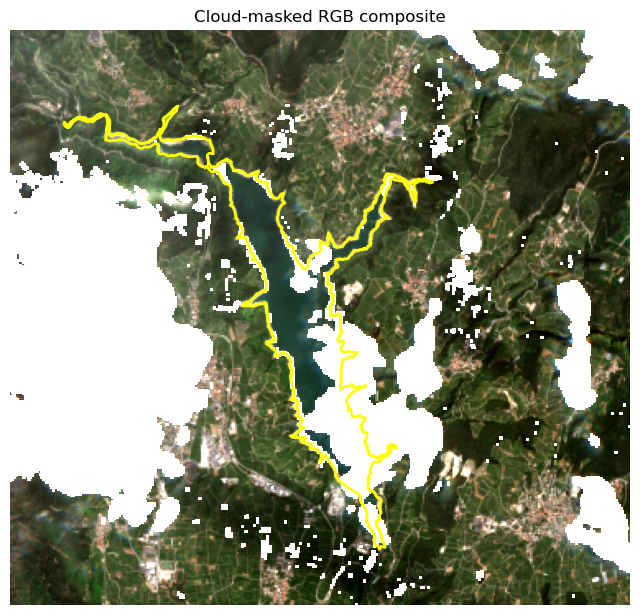

In [14]:
valid_classes = [2, 4, 5, 6]

mask = datacube["scl"].isin(valid_classes)

datacube_masked = datacube.where(mask)

datacube_sample = datacube_masked.isel(time=50)

rgb = datacube_sample[["b04", "b03", "b02"]].to_dataarray(dim="band")

rgb = rgb.assign_coords(band=["red", "green", "blue"])

vmin, vmax = 0, 0.25
rgb_scaled = (rgb - vmin) / (vmax - vmin)
rgb_scaled = rgb_scaled.clip(0, 1)  # keep in [0, 1]
rgb_img = rgb_scaled.transpose("y", "x", "band").values

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(
    rgb_img,
    extent=[
        float(rgb.x.min()),
        float(rgb.x.max()),
        float(rgb.y.min()),
        float(rgb.y.max()),
    ],
)
lake_gdf.boundary.plot(ax=ax, edgecolor="yellow", linewidth=2)
ax.set_title("Cloud-masked RGB composite")
ax.axis("off")
plt.show()

We keep only the dates with a cloud coverage less than 5% over the lake:

In [15]:
valid_classes = [4, 5, 6]
threshold = 0.05

datacube_lake = datacube.rio.clip(lake_gdf.geometry, lake_gdf.crs)

clear_mask = datacube_lake["scl"].isin(valid_classes)

clear_fraction = clear_mask.mean(dim=("y", "x")).compute()

mask_good = clear_fraction >= threshold

datacube_clear = datacube_lake.isel(time=mask_good)
datacube_clear

<xarray.Dataset> Size: 571MB
Dimensions:      (time: 240, x: 222, y: 268)
Coordinates:
  * time         (time) object 2kB 1610100799024000000 ... 1702980871024000000
  * x            (x) float32 888B 6.548e+05 6.548e+05 ... 6.592e+05 6.592e+05
  * y            (y) float32 1kB 5.14e+06 5.14e+06 ... 5.135e+06 5.135e+06
    spatial_ref  int64 8B 0
Data variables:
    b02          (time, y, x) float64 114MB dask.array<chunksize=(1, 268, 4), meta=np.ndarray>
    b03          (time, y, x) float64 114MB dask.array<chunksize=(1, 268, 4), meta=np.ndarray>
    b04          (time, y, x) float64 114MB dask.array<chunksize=(1, 268, 4), meta=np.ndarray>
    b8a          (time, y, x) float64 114MB dask.array<chunksize=(1, 268, 4), meta=np.ndarray>
    scl          (time, y, x) float64 114MB dask.array<chunksize=(1, 268, 4), meta=np.ndarray>

(Ndwi_water)=

## NDWI

Water detection is performed using the Normalized Difference Water Index (NDWI), which utilizes the green and near-infrared (NIR) bands of the Sentinel-2 imagery. The NDWI is calculated as follows:

$$ NDWI = \frac {GREEN - NIR} {GREEN + NIR} $$

In [16]:
ndwi = (datacube_clear["b03"] - datacube_clear["b8a"]) / (
    datacube_clear["b03"] + datacube_clear["b8a"]
)

(Water_detection_water)=

## Water detection

The water area is selected applying Otsu Thresholding:

In [17]:
def otsu_mask(arr):
    arr = np.clip(np.nan_to_num(arr, nan=0.0), -1, 1)

    valid = arr > -0.2
    if np.count_nonzero(valid) < 10:
        return np.zeros_like(arr, dtype=bool)
    try:
        thr = threshold_otsu(arr[valid])
    except Exception:
        thr = 0.0
    thr -= 0.05

    return arr > thr


ndwi = ndwi.chunk({"x": -1, "y": -1})
water_masks = xr.apply_ufunc(
    otsu_mask,
    ndwi,
    input_core_dims=[["y", "x"]],
    output_core_dims=[["y", "x"]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[bool],
)

water_masks.compute()

water_masks

<xarray.DataArray (time: 240, y: 268, x: 222)> Size: 14MB
dask.array<transpose, shape=(240, 268, 222), dtype=bool, chunksize=(1, 268, 222), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) object 2kB 1610100799024000000 ... 1702980871024000000
  * x            (x) float32 888B 6.548e+05 6.548e+05 ... 6.592e+05 6.592e+05
  * y            (y) float32 1kB 5.14e+06 5.14e+06 ... 5.135e+06 5.135e+06
    spatial_ref  int64 8B 0

Sample visualization of computed water mask:

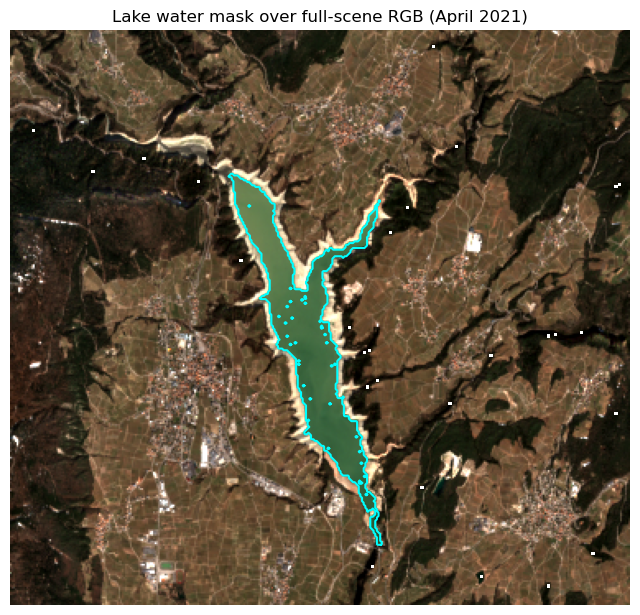

In [18]:
target_time = "2021-04"

datacube_full_rgb = datacube.sel(time=target_time, method="nearest")[
    ["b04", "b03", "b02"]
].to_dataarray("band")
datacube_full_rgb = datacube_full_rgb.assign_coords(band=["red", "green", "blue"])

vmin, vmax = 0, 0.25
rgb_scaled_full = (datacube_full_rgb - vmin) / (vmax - vmin)
rgb_scaled_full = rgb_scaled_full.clip(0, 1)
rgb_img_full = rgb_scaled_full.transpose("y", "x", "band").values

water_mask_da = water_masks.sel(time=target_time, method="nearest")

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(
    rgb_img_full,
    extent=[
        float(datacube_full_rgb.x.min()),
        float(datacube_full_rgb.x.max()),
        float(datacube_full_rgb.y.min()),
        float(datacube_full_rgb.y.max()),
    ],
)

water_mask = water_mask_da.values
x_coords = water_mask_da.x.values
y_coords = water_mask_da.y.values

contours = measure.find_contours(water_mask, 0.5)
for contour in contours:
    x_contour = np.interp(contour[:, 1], np.arange(len(x_coords)), x_coords)
    y_contour = np.interp(contour[:, 0], np.arange(len(y_coords)), y_coords)

    ax.plot(x_contour, y_contour, color="cyan", linewidth=1.5)

ax.set_title("Lake water mask over full-scene RGB (April 2021)")
ax.axis("off")
plt.show()

In [19]:
lake_masked = []

for t in range(len(datacube_clear.time)):
    wm = xr.DataArray(
        water_masks[t],
        dims=("y", "x"),
        coords={"y": datacube_clear.y, "x": datacube_clear.x},
        name="water_mask",
    ).rio.write_crs(datacube_clear.rio.crs)

    mask = geometry_mask(
        [lake_gdf.geometry.unary_union],
        transform=wm.rio.transform(),
        invert=True,
        out_shape=wm.shape,
    )
    wm_clipped = wm.where(mask)
    lake_masked.append(wm_clipped)

water_masks_clipped = xr.concat(lake_masked, dim="time")

In [20]:
water_fraction = water_masks_clipped.sum(dim=("y", "x")) / (
    water_masks_clipped.notnull().sum(dim=("y", "x"))
)

(Water_surface_area_extraction_water)=

## Water surface area extraction


In [21]:
df_water = pd.DataFrame(
    {"time": water_fraction.time.values, "water_fraction": water_fraction.values}
)
df_water.set_index("time", inplace=True)

In [22]:
pixel_area_m2 = 20 * 20

water_pixel_count = (water_masks_clipped == 1).sum(dim=("y", "x"))
water_area_m2 = water_pixel_count * pixel_area_m2

water_area_m2 = water_area_m2.assign_coords(time=water_masks_clipped.time)

dates = pd.to_datetime(water_masks.time.values)

water_area_ts = pd.Series(water_area_m2.values, index=dates)

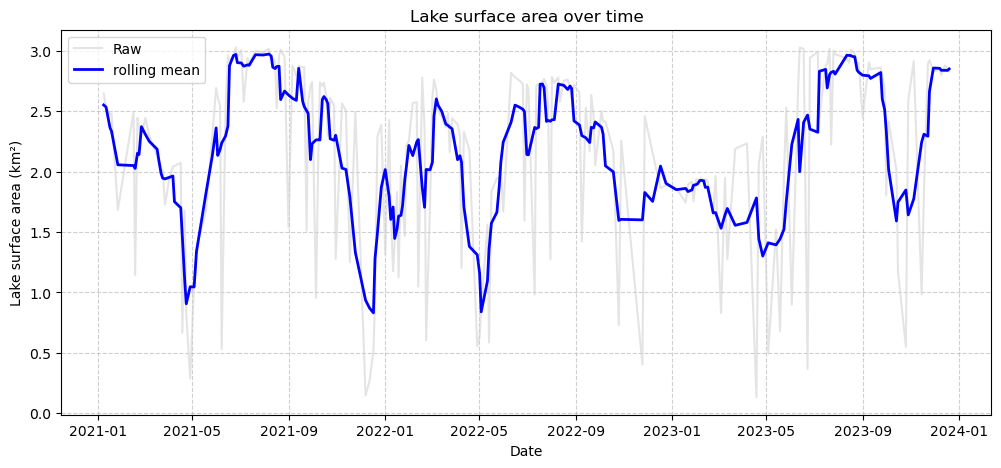

In [23]:
smoothed = water_area_ts.rolling(window=5, center=True, min_periods=1).mean()

plt.figure(figsize=(12, 5))
plt.plot(
    water_area_ts.index,
    water_area_ts.values / 1e6,
    color="lightgray",
    alpha=0.6,
    label="Raw",
)
plt.plot(
    smoothed.index,
    smoothed.values / 1e6,
    color="blue",
    linewidth=2,
    label="rolling mean",
)
plt.ylabel("Lake surface area (km²)")
plt.xlabel("Date")
plt.title("Lake surface area over time")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()

In [24]:
cluster.shutdown()

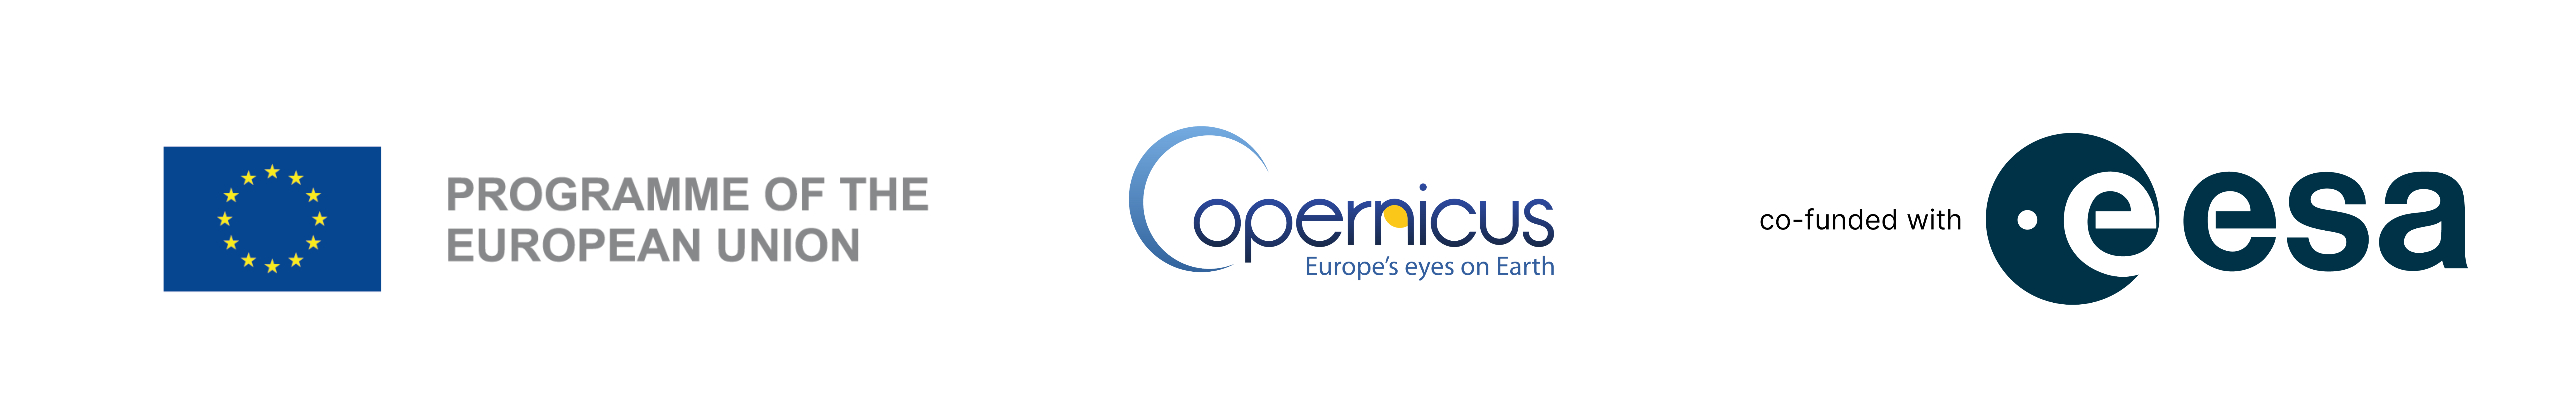
